Загрузка и первичный анализ данных

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('auto-mpg.csv')

display(df.head(35))
display(df.describe())

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl


,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [101]:
print(df.isnull().sum()) # показал что нет пропусков, но в столбце horsepower есть значения '?', которые нужно заменить на NaN и потом заполнить медианой
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
print(df.isnull().sum())

median_hp = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(median_hp)
print(df.isnull().sum())

display(df.describe())

df = df.drop('car name', axis=1)

categorical_cols = ['cylinders', 'model year', 'origin']
for col in categorical_cols:
    df[col] = df[col].astype('category')

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.304020,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.222625,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


Исследовательский анализ

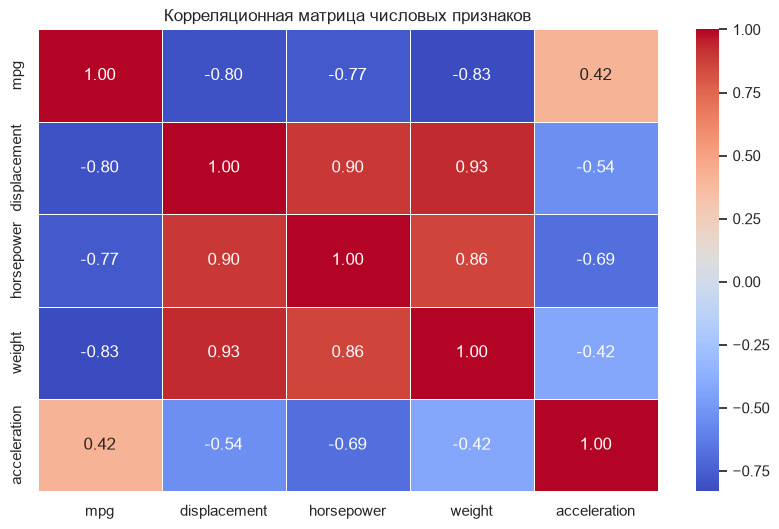


Корреляция с целевой переменной (mpg):
mpg             1.000000
acceleration    0.420289
horsepower     -0.773453
displacement   -0.804203
weight         -0.831741
Name: mpg, dtype: float64


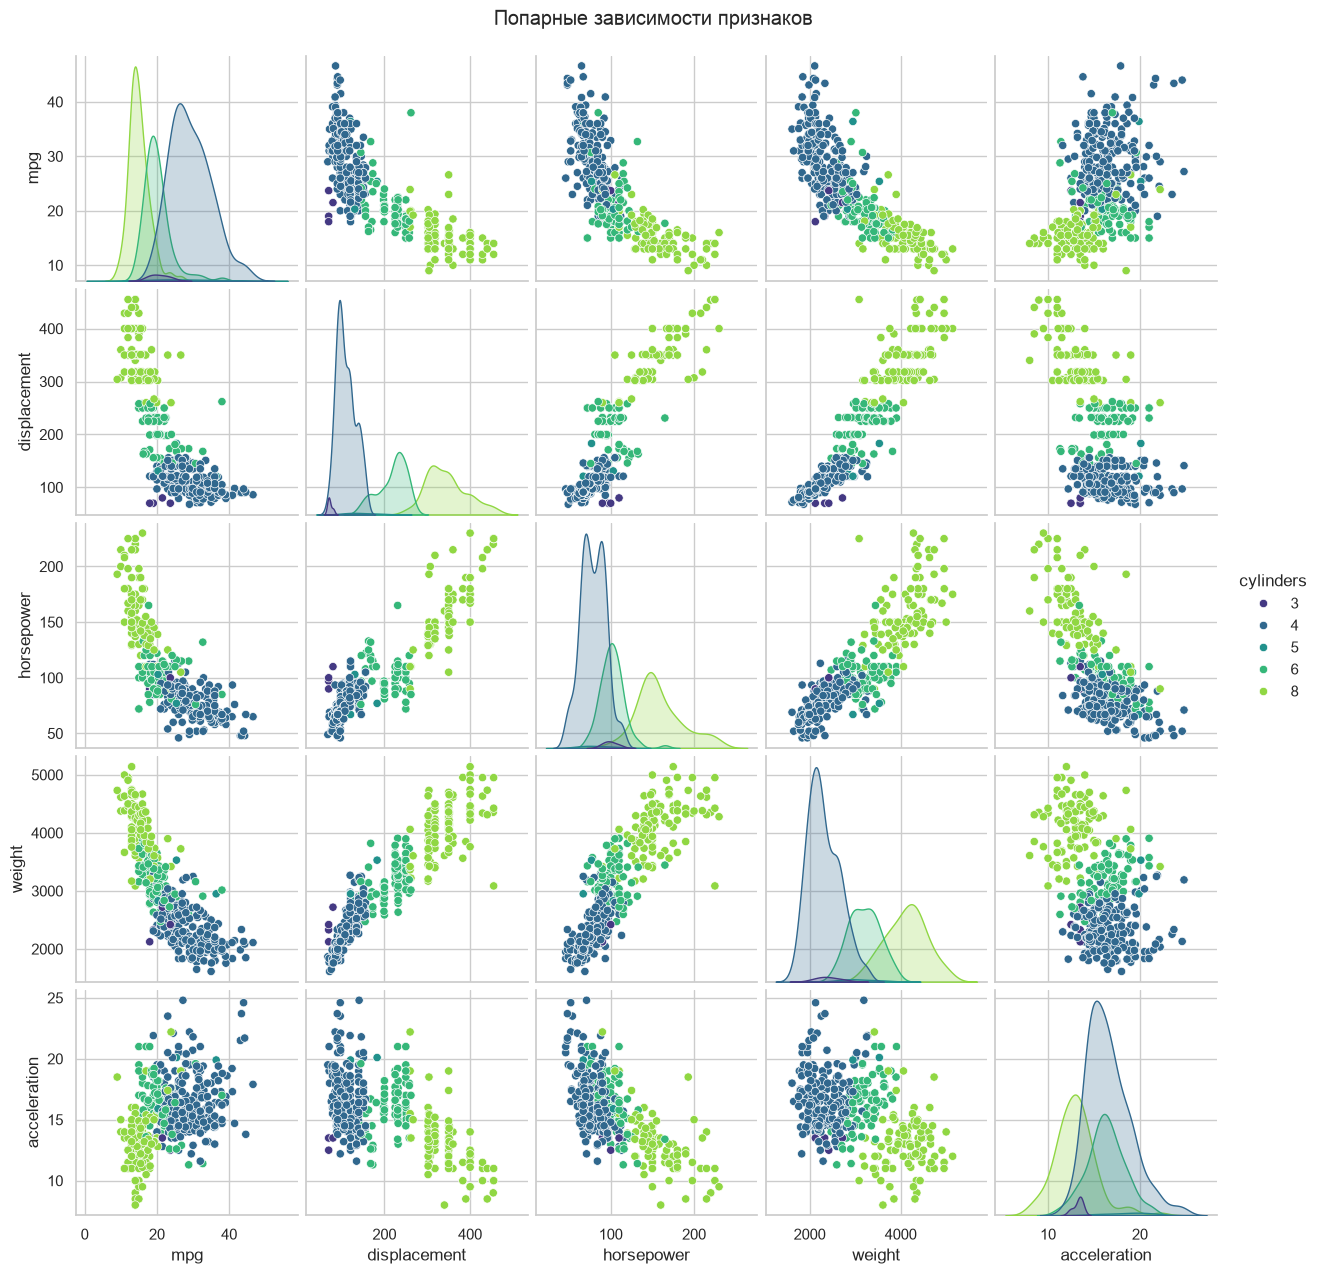

In [102]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

numeric_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

print("\nКорреляция с целевой переменной (mpg):")
print(corr_matrix['mpg'].sort_values(ascending=False))

sns.pairplot(df, vars=['mpg', 'displacement', 'horsepower', 'weight', 'acceleration'], 
             hue='cylinders', palette='viridis', diag_kind='kde')
plt.suptitle('Попарные зависимости признаков', y=1.02)
plt.show()

Сильнее всего с mpg коррелируют weight (-0.83), displacement (-0.80) и horsepower (-0.77). На графиках pairplot явно видны нелинейные зависимости между mpg и объемом двигателя, что обосновывает необходимость полиномиальных признаков.

Подготовка данных и построение базовой модели

In [103]:
from sklearn.model_selection import train_test_split

X = df.drop('mpg', axis=1)
Y = df['mpg']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

print(f"Train set: {X_train.shape[0]} объектов")
print(f"Test set: {X_test.shape[0]} объектов")

Train set: 278 объектов
Test set: 120 объектов


In [104]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [105]:
num_cols = ['displacement', 'horsepower', 'weight', 'acceleration']
cat_cols = ['cylinders', 'model year', 'origin']

X_train_cat = pd.get_dummies(X_train[cat_cols], drop_first=True)
X_test_cat = pd.get_dummies(X_test[cat_cols], drop_first=True)

scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train[num_cols])
X_test_num_scaled = scaler.transform(X_test[num_cols])

X_train_base = np.hstack([X_train_num_scaled, X_train_cat.values])
X_test_base = np.hstack([X_test_num_scaled, X_test_cat.values])

lr_base = LinearRegression()
lr_base.fit(X_train_base, Y_train)

Y_train_pred_base = lr_base.predict(X_train_base)
Y_test_pred_base = lr_base.predict(X_test_base)

print(f"Train MSE: {mean_squared_error(Y_train, Y_train_pred_base):.4f}, R2: {r2_score(Y_train, Y_train_pred_base):.4f}")
print(f"Test  MSE: {mean_squared_error(Y_test, Y_test_pred_base):.4f}, R2: {r2_score(Y_test, Y_test_pred_base):.4f}")
print(f"Разница в R2 между обучающей и тестовой выборками: {abs(r2_score(Y_train, Y_train_pred_base) - r2_score(Y_test, Y_test_pred_base)):.4f}") 

Train MSE: 8.0059, R2: 0.8718
Test  MSE: 7.8765, R2: 0.8628
Разница в R2 между обучающей и тестовой выборками: 0.0090


Построение и подбор степени полинома

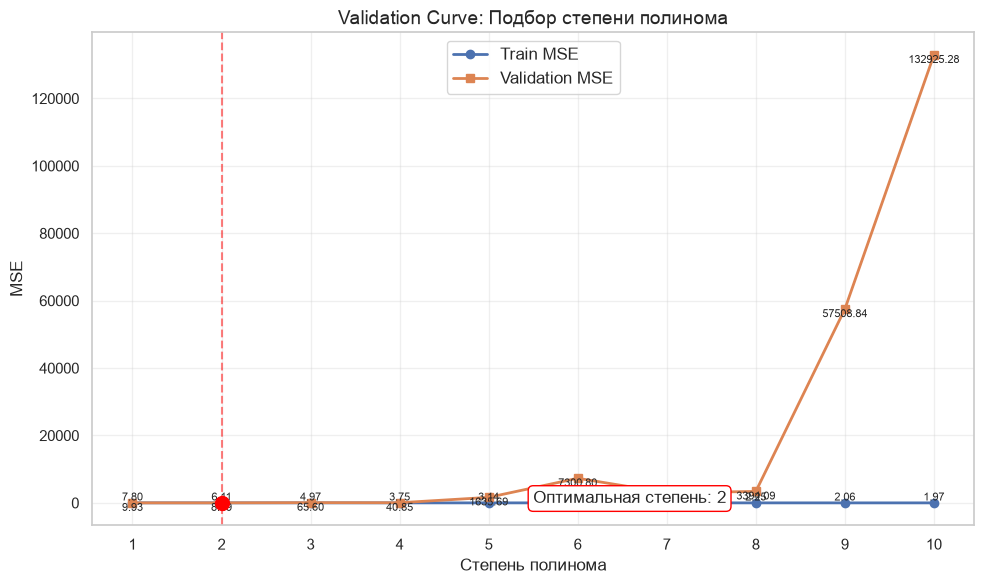

Оптимальная степень полинома по минимуму Validation MSE: 2
Минимальное Validation MSE: 8.5884
Разница между Validation MSE для степени 1 и 2: 1.345397


In [106]:
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import validation_curve
from sklearn.linear_model import LinearRegression

def make_poly_pipeline(degree, model=LinearRegression()):
    prep = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                ('scaler', StandardScaler()),
            ]), num_cols),
            ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
        ])
    return Pipeline(steps=[('preprocessor', prep), ('regressor', model)])

degrees = np.arange(1, 11)

train_scores, val_scores = validation_curve(
    make_poly_pipeline(degree=1),
    X_train, Y_train,
    param_name="preprocessor__num__poly__degree",
    param_range=degrees,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

train_mse = -train_scores.mean(axis=1)
val_mse = -val_scores.mean(axis=1)

plt.figure(figsize=(10, 6))

plt.plot(degrees, train_mse, label='Train MSE', marker='o', linewidth=2)
plt.plot(degrees, val_mse, label='Validation MSE', marker='s', linewidth=2)

optimal_idx = np.argmin(val_mse)
plt.axvline(x=degrees[optimal_idx], color='red', linestyle='--', alpha=0.5)
plt.scatter(degrees[optimal_idx], val_mse[optimal_idx], color='red', s=100, zorder=5)

for i, (t, v) in enumerate(zip(train_mse, val_mse)):
    plt.text(degrees[i], t + 0.05, f'{t:.2f}', ha='center', va='bottom', fontsize=8)
    plt.text(degrees[i], v - 0.05, f'{v:.2f}', ha='center', va='top', fontsize=8)

plt.xlabel('Степень полинома', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Validation Curve: Подбор степени полинома', fontsize=14)
plt.legend(fontsize=12)
plt.xticks(degrees)
plt.grid(True, alpha=0.3)

plt.text(5.5, 9.0, f'Оптимальная степень: {degrees[optimal_idx]}', 
         fontsize=12, bbox=dict(boxstyle="round", facecolor='white', edgecolor='red'))

plt.tight_layout()
plt.show()

print(f"Оптимальная степень полинома по минимуму Validation MSE: {degrees[optimal_idx]}")
print(f"Минимальное Validation MSE: {val_mse[optimal_idx]:.4f}")
print(f"Разница между Validation MSE для степени 1 и 2: {abs(val_mse[0] - val_mse[1]):.6f}")


Оптимальная степень по минимуму Validation MSE: 2.
Наблюдается заметное снижение Validation MSE при переходе от степени 1 к степени 2. Дальнейшее увеличение степени не улучшает результат

Регуляризация

/Users/stimushev/Documents/Inopolis/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.151936e+00, tolerance: 1.316e+00
  model = cd_fast.enet_coordinate_descent(
/Users/stimushev/Documents/Inopolis/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.312069e+00, tolerance: 1.316e+00
  model = cd_fast.enet_coordinate_descent(
/Users/stimushev/Documents/Inopolis/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

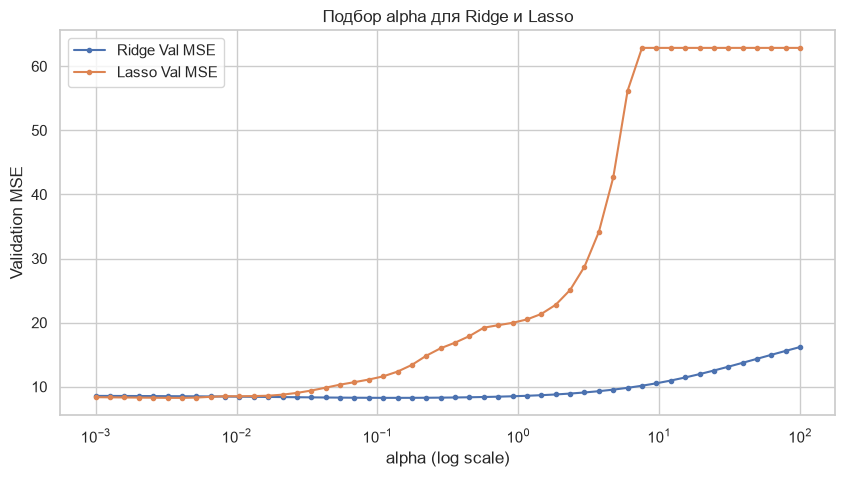

Оптимальный alpha для Ridge: 0.1389
Оптимальный alpha для Lasso: 0.0041


In [107]:
from sklearn.linear_model import Ridge, Lasso

optimal_degree = 2 

alphas = np.logspace(-3, 2, 50)

pipeline_ridge = make_poly_pipeline(optimal_degree, Ridge())
train_scores_r, val_scores_r = validation_curve(
    pipeline_ridge, X_train, Y_train,
    param_name="regressor__alpha", param_range=alphas,
    cv=5, scoring="neg_mean_squared_error", n_jobs=-1
)

pipeline_lasso = make_poly_pipeline(optimal_degree, Lasso(max_iter=10000))
train_scores_l, val_scores_l = validation_curve(
    pipeline_lasso, X_train, Y_train,
    param_name="regressor__alpha", param_range=alphas,
    cv=5, scoring="neg_mean_squared_error", n_jobs=-1
)

plt.figure(figsize=(10, 5))
plt.semilogx(alphas, -val_scores_r.mean(axis=1), label='Ridge Val MSE', marker='.')
plt.semilogx(alphas, -val_scores_l.mean(axis=1), label='Lasso Val MSE', marker='.')
plt.xlabel('alpha (log scale)')
plt.ylabel('Validation MSE')
plt.title('Подбор alpha для Ridge и Lasso')
plt.legend()
plt.show()

best_alpha_ridge = alphas[np.argmin(-val_scores_r.mean(axis=1))]
best_alpha_lasso = alphas[np.argmin(-val_scores_l.mean(axis=1))]

print(f"Оптимальный alpha для Ridge: {best_alpha_ridge:.4f}")
print(f"Оптимальный alpha для Lasso: {best_alpha_lasso:.4f}")

In [108]:
final_lasso_pipeline = make_poly_pipeline(optimal_degree, Lasso(alpha=best_alpha_lasso, max_iter=10000))
final_lasso_pipeline.fit(X_train, Y_train)

lasso_model = final_lasso_pipeline.named_steps['regressor']
coefficients = lasso_model.coef_

non_zero_count = np.sum(coefficients != 0)
total_count = len(coefficients)

print(f"Анализ Lasso (alpha={best_alpha_lasso:.4f}):")
print(f"Всего признаков после полиномизации: {total_count}")
print(f"Признаков с ненулевыми весами (отобрано Lasso): {non_zero_count}")
print(f"Признаков обнулено (отсеяно Lasso): {total_count - non_zero_count}")


Анализ Lasso (alpha=0.0041):
Всего признаков после полиномизации: 32
Признаков с ненулевыми весами (отобрано Lasso): 26
Признаков обнулено (отсеяно Lasso): 6


Итоговое сравнение и выводы

In [109]:
from sklearn.metrics import mean_squared_error, r2_score

model_base = LinearRegression()
model_base.fit(X_train_base, Y_train)
pred_base = model_base.predict(X_test_base)

model_poly_lr = make_poly_pipeline(optimal_degree, LinearRegression())
model_poly_lr.fit(X_train, Y_train)
pred_poly_lr = model_poly_lr.predict(X_test)

model_poly_ridge = make_poly_pipeline(optimal_degree, Ridge(alpha=best_alpha_ridge))
model_poly_ridge.fit(X_train, Y_train)
pred_poly_ridge = model_poly_ridge.predict(X_test)

results = pd.DataFrame({
    'Модель': ['1. Baseline (Linear)', f'2. Poly LR (degree={optimal_degree})', f'3. Poly Ridge (alpha={best_alpha_ridge:.3f})'],
    'Test MSE': [
        mean_squared_error(Y_test, pred_base),
        mean_squared_error(Y_test, pred_poly_lr),
        mean_squared_error(Y_test, pred_poly_ridge)
    ],
    'Test R2': [
        r2_score(Y_test, pred_base),
        r2_score(Y_test, pred_poly_lr),
        r2_score(Y_test, pred_poly_ridge)
    ]
})

display(results.round(4))

,Модель,Test MSE,Test R2
0,1. Baseline (Linear),7.8765,0.8628
1,2. Poly LR (degree=2),6.0268,0.8950
2,3. Poly Ridge (alpha=0.139),5.9675,0.8960


1. Улучшила ли полиномиализация качество по сравнению с линейной моделью?
  Да, полиномиализация улучшило качество значительно
  MSE снизился с 7.8765 до 6.0268
  R² увеличился с 0.8628 до 0.8950

2. Помогла ли регуляризация (Ridge) улучшить результат на тесте?
  Нет, не помогла, но и не ухудшила

In [110]:
lasso_model = final_lasso_pipeline.named_steps['regressor']
coefficients = lasso_model.coef_
preprocessor = final_lasso_pipeline.named_steps['preprocessor']

poly_transformer = preprocessor.named_transformers_['num'].named_steps['poly']
num_feature_names = poly_transformer.get_feature_names_out(num_cols)

cat_transformer = preprocessor.named_transformers_['cat']
cat_feature_names = cat_transformer.get_feature_names_out(cat_cols)

all_feature_names = list(num_feature_names) + list(cat_feature_names)

coef_df = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': coefficients
})

coef_df['abs_coef'] = np.abs(coef_df['coefficient'])

coef_df_sorted = coef_df.sort_values('abs_coef', ascending=False)

print("Важные признаки по версии Lasso:")
print(coef_df_sorted.head(10))

print("\nПризнаки, которые Lasso обнулил (коэффициент ≈ 0):")
zero_coef = coef_df_sorted[np.abs(coef_df_sorted['coefficient']) < 1e-6]
print(zero_coef[['feature', 'coefficient']])

Важные признаки по версии Lasso:
          feature  coefficient  abs_coef
2          weight    -9.858556  9.858556
27  model year_80     8.585128  8.585128
29  model year_82     8.165569  8.165569
28  model year_81     5.671575  5.671575
17    cylinders_8     5.467419  5.467419
11       weight^2     5.375385  5.375385
15    cylinders_5     4.876876  4.876876
16    cylinders_6     4.835929  4.835929
26  model year_79     4.404965  4.404965
14    cylinders_4     4.331346  4.331346

Признаки, которые Lasso обнулил (коэффициент ≈ 0):
                      feature  coefficient
21              model year_74         -0.0
7   displacement acceleration          0.0
5     displacement horsepower          0.0
4              displacement^2          0.0
3                acceleration          0.0
1                  horsepower         -0.0


Вес сильнее всех влияет на расход
Так же год выпуска авто влияет на его расход
Мощность и разгон не влияют на расход топлива или влияют незначительно поэтому были удалены как признаки